# Attention-based earthquake catalog continuation (with `eq_mag_prediction`)

This notebook is the same MTPP-Transformer + MDN pipeline as `MPP_transformer.ipynb`, but **NLL, mixture means, and input scaling** use utilities from the **`eq_mag_prediction` package** (`metrics.gaussian_mixture_instance`, `ml_utils.StandardScaler`).

The model maps continuous inter-event times (`dt`) and magnitudes (`m`) and fits mixture densities for both targets.


In [1]:
# Interactive Matplotlib (zoom/pan toolbar). Requires: pip install ipympl
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import os

from eq_mag_prediction.forecasting import metrics
from eq_mag_prediction.utilities import catalog_analysis
from eq_mag_prediction.utilities import ml_utils


I0000 00:00:1777376079.567366    6457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777376079.576891    6457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777376080.032450    6457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777376083.221563    6457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Stage 1: Input Data Not String
Instead of transforming the data to strings like `'t100m3.2'` and using a standard tokenizer, we feed the network a sequence of continuous vectors. We extract inter-event times (`dt`) and `magnitude`, normalize them, and use `tf.data.Dataset`.

In [2]:
def create_tf_dataset(
    csv_file,
    seq_length=100,
    batch_size=32,
    max_sequences=None,
    shuffle_buffer=10000,
    train_fraction=0.8,
):
    """Train/test sliding-window data. The scaler is fit on training pairs only."""
    if not os.path.exists(csv_file):
        return None

    df = pd.read_csv(csv_file)
    df = df.sort_values(by="time").reset_index(drop=True)
    n_ev = len(df)
    if n_ev < seq_length + 3:
        return None

    time = df["time"].values.astype(np.float64)
    magnitude = df["magnitude"].values.astype(np.float64)
    n_pair = n_ev - 1
    dt = np.diff(time)
    mag = magnitude[1:]
    raw = np.stack([dt, mag], axis=-1)

    n_train_ev = max(2, min(int(np.floor(train_fraction * n_ev)), n_ev - 1))
    n_train_pair = n_train_ev - 1
    if n_train_pair < seq_length + 1:
        return None

    scaler = ml_utils.StandardScaler(feature_axes=0)
    scaler.fit(raw[:n_train_pair])
    data = np.asarray(scaler.transform(raw), dtype=np.float32)

    i_train_max = n_train_pair - seq_length
    i_test0 = n_train_pair - seq_length + 1
    if i_test0 < n_pair - seq_length and i_test0 >= 0:
        test_window_starts = np.arange(
            i_test0, n_pair - seq_length, dtype=np.int32
        )
    else:
        test_window_starts = np.array([], dtype=np.int32)

    def build_xy(indices):
        X, y = [], []
        for i in indices:
            i = int(i)
            X.append(data[i : i + seq_length])
            y.append(data[i + 1 : i + seq_length + 1])
        if not X:
            return None, None
        return (np.array(X, dtype=np.float32), np.array(y, dtype=np.float32))

    train_indices = list(range(0, i_train_max + 1))
    if max_sequences is not None:
        train_indices = train_indices[: max_sequences]
    Xtr, ytr = build_xy(train_indices)
    if Xtr is None:
        return None

    test_is = [int(t) for t in test_window_starts]
    if max_sequences is not None:
        cap = max(64, max_sequences // 4)
        test_is = test_is[: min(len(test_is), cap)]
    Xte, yte = build_xy(test_is) if test_is else (None, None)

    buf = min(shuffle_buffer, len(Xtr)) if len(Xtr) > 0 else 1
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((Xtr, ytr))
        .shuffle(buf)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    if Xte is not None and len(Xte) > 0:
        bsz = min(int(batch_size), int(len(Xte)))
        bsz = max(1, bsz)
        test_dataset = (
            tf.data.Dataset.from_tensor_slices((Xte, yte))
            .batch(bsz)
            .prefetch(tf.data.AUTOTUNE)
        )
    else:
        test_dataset = None
        test_is = []

    return {
        "train_dataset": train_dataset,
        "test_dataset": test_dataset,
        "scaler": scaler,
        "df": df,
        "n_train_events": n_train_ev,
        "time": time,
        "test_window_starts": np.array(test_is, dtype=np.int32)
        if test_is
        else np.array([], dtype=np.int32),
        "num_train_sequences": int(len(Xtr)),
    }


### Stage 2: Continuous Positional Encoding
Standard sequence position encodings (like those in NLP) represent token order. Since our data occurs at irregular intervals, we explicitly map the continuous `dt` through sinusoidal functions.

In [3]:
class ContinuousTimeEncoding(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(1, self.d_model),
            initializer='glorot_uniform',
            trainable=True,
            name='time_freqs'
        )

    def call(self, dt):
        time_enc = dt * self.w
        return tf.sin(time_enc)


### Stage 3 & 4: Transformer Architecture & MDN Head
The self-attention mechanism replaces the standard ETAS kernel. The output head uses a Mixture Density Network to output continuous probability distributions, bypassing the 'non-trained tokens' problem entirely.

In [4]:
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, nhead, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=nhead, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * 4, activation='relu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False, attention_mask=None):
        attn_output = self.att(inputs, inputs, attention_mask=attention_mask)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + ffn_output)

class MTPPTransformer(Model):
    def __init__(self, d_model=64, nhead=4, num_layers=2, num_mixtures=5, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_mixtures = num_mixtures
        
        self.input_proj = layers.Dense(d_model)
        self.time_encoding = ContinuousTimeEncoding(d_model)
        self.transformer_blocks = [TransformerBlock(d_model, nhead) for _ in range(num_layers)]
        
        self.mdn_pi = layers.Dense(num_mixtures * 2) 
        self.mdn_mu = layers.Dense(num_mixtures * 2)
        self.mdn_sigma = layers.Dense(num_mixtures * 2)

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]
        seq_length = tf.shape(x)[1]
        
        dt = tf.expand_dims(x[:, :, 0], -1)
        h = self.input_proj(x) + self.time_encoding(dt)
        attn_mask = tf.linalg.band_part(
            tf.ones((seq_length, seq_length), dtype=tf.bool), -1, 0
        )
        attn_mask = tf.reshape(attn_mask, [1, seq_length, seq_length])
        attn_mask = tf.broadcast_to(attn_mask, [batch_size, seq_length, seq_length])

        for block in self.transformer_blocks:
            h = block(h, training=training, attention_mask=attn_mask)
        
        pi_logits = tf.reshape(self.mdn_pi(h), [batch_size, seq_length, 2, self.num_mixtures])
        pi = tf.nn.softmax(pi_logits, axis=-1)
        
        mu = tf.reshape(self.mdn_mu(h), [batch_size, seq_length, 2, self.num_mixtures])
        
        sigma_logits = tf.reshape(self.mdn_sigma(h), [batch_size, seq_length, 2, self.num_mixtures])
        sigma = tf.exp(sigma_logits)
        
        return pi, mu, sigma


### Training configuration and loss
The model is trained to minimize the negative log-likelihood of the true \(\Delta t\) and magnitudes. The loss uses `eq_mag_prediction.forecasting.metrics.gaussian_mixture_instance` (TensorFlow Probability) to evaluate each bivariate GMM head, instead of a hand-rolled log-density.


In [5]:
def mdn_nll_bivariate(pi, mu, sigma, target):
    """Negative log-likelihood for two GMM output heads via `metrics.gaussian_mixture_instance` (TFP)."""
    n_mix = int(pi.shape[-1])
    target = tf.cast(target, tf.float32)
    loss_terms = []
    for d in range(2):
        p = tf.reshape(pi[:, :, d, :], (-1, n_mix))
        m = tf.reshape(mu[:, :, d, :], (-1, n_mix))
        s = tf.reshape(sigma[:, :, d, :], (-1, n_mix))
        fore = tf.concat([m, s, p], axis=-1)
        dist = metrics.gaussian_mixture_instance(fore)
        y = tf.reshape(target[:, :, d], (-1,))
        loss_terms.append(-tf.reduce_mean(dist.log_prob(y)))
    return 0.5 * tf.add_n(loss_terms)


def mixture_posterior_mean(pi, mu, sigma):
    """Posterior mean per (batch, time, feature) from the same GMM as training."""
    n_mix = int(pi.shape[-1])
    out = []
    b = tf.shape(pi)[0]
    s_ = tf.shape(pi)[1]
    for d in range(2):
        p = tf.reshape(pi[:, :, d, :], (-1, n_mix))
        m = tf.reshape(mu[:, :, d, :], (-1, n_mix))
        s = tf.reshape(sigma[:, :, d, :], (-1, n_mix))
        fore = tf.concat([m, s, p], axis=-1)
        mean_1d = metrics.gaussian_mixture_instance(fore).mean()
        out.append(tf.reshape(mean_1d, [b, s_]))
    return tf.stack(out, axis=-1)


In [6]:
# Quick smoke test: small context, capped sequences, few batches per epoch.
# Set to False for a longer run on the full sliding-window dataset.
QUICK_TEST = False
INTERMEDIATE_TEST = True

training_completed = False
data_pack = None

if QUICK_TEST:
    seq_length = 16
    batch_size = 16
    epochs = 2
    d_model = 32
    max_sequences = 512
    max_steps_per_epoch = 20
    nhead, num_layers, num_mixtures = 4, 1, 3
    shuffle_buffer = 512
    # catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/example_catalog.csv'
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/hauksson.csv'
elif INTERMEDIATE_TEST:
    seq_length = 16
    batch_size = 16
    epochs = 10
    d_model = 32
    max_sequences = 512
    max_steps_per_epoch = 20
    nhead, num_layers, num_mixtures = 4, 1, 3
    shuffle_buffer = 512
    # catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/example_catalog.csv'
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/hauksson.csv'
else:
    seq_length = 50
    batch_size = 32
    epochs = 10
    d_model = 64
    max_sequences = None
    max_steps_per_epoch = None
    nhead, num_layers, num_mixtures = 4, 2, 5
    shuffle_buffer = 10000
    catalog_path = '/home/neriberman/REPOS/eq_mag_prediction/results/catalogs/ingested/hauksson.csv'

data_pack = create_tf_dataset(
    catalog_path,
    seq_length=seq_length,
    batch_size=batch_size,
    max_sequences=max_sequences,
    shuffle_buffer=shuffle_buffer,
    train_fraction=0.8,
)
epoch_loss_history = []

if data_pack is None:
    print(f"Catalog not found or too small: {catalog_path}")
else:
    training_completed = True
    mode = 'QUICK_TEST' if QUICK_TEST else 'full'
    num_sequences = data_pack['num_train_sequences']
    train_dataset = data_pack['train_dataset']
    dataset = train_dataset  # for scatter cells below
    scaler = data_pack['scaler']
    print(f"[{mode}] Sequences in this run: {num_sequences} | seq_length={seq_length}")

    model = MTPPTransformer(
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        num_mixtures=num_mixtures,
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    @tf.function
    def train_step(batch_x, batch_y):
        with tf.GradientTape() as tape:
            pi, mu, sigma = model(batch_x, training=True)
            loss = mdn_nll_bivariate(pi, mu, sigma, batch_y)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    print("Starting training...")
    for epoch in range(epochs):
        total_loss = 0.0
        steps = 0

        for batch_x, batch_y in train_dataset:
            loss = train_step(batch_x, batch_y)
            total_loss += loss
            steps += 1
            if max_steps_per_epoch is not None and steps >= max_steps_per_epoch:
                break

        avg_loss = total_loss / steps if steps > 0 else 0
        epoch_loss_history.append(float(avg_loss))
        print(f"Epoch {epoch+1}/{epochs} | Average NLL Loss: {avg_loss:.4f} (steps={steps})")


E0000 00:00:1777376089.358013    6457 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[full] Sequences in this run: 512 | seq_length=16
Starting training...
Epoch 1/10 | Average NLL Loss: 2.0167 (steps=20)
Epoch 2/10 | Average NLL Loss: 1.3353 (steps=20)
Epoch 3/10 | Average NLL Loss: 1.2362 (steps=20)
Epoch 4/10 | Average NLL Loss: 1.1645 (steps=20)
Epoch 5/10 | Average NLL Loss: 1.0763 (steps=20)
Epoch 6/10 | Average NLL Loss: 1.0776 (steps=20)
Epoch 7/10 | Average NLL Loss: 1.0312 (steps=20)
Epoch 8/10 | Average NLL Loss: 1.0128 (steps=20)
Epoch 9/10 | Average NLL Loss: 0.9687 (steps=20)
Epoch 10/10 | Average NLL Loss: 1.0504 (steps=20)


## Generate continuation

In [7]:
# --- Autoregressive catalog generation (uses the same `ml_utils.StandardScaler` as training) ---

def _std_safe_1d(scaler):
    s = np.asarray(scaler.std, dtype=np.float64).reshape(2,).copy()
    s[s == 0.0] = 1.0
    m = np.asarray(scaler.mean, dtype=np.float64).reshape(2,)
    return m, s


def generate_catalog(model, initial_sequence, num_events, scaler, seq_length):
    m1, s1 = _std_safe_1d(scaler)
    m_dt, m_mag, s_dt, s_mag = float(m1[0]), float(m1[1]), float(s1[0]), float(s1[1])
    current_seq = tf.identity(initial_sequence)
    rows = []

    for _ in range(num_events):
        pi, mu, sigma_ = model(current_seq, training=False)
        p_l = pi[0, -1, :, :]
        mu_l = mu[0, -1, :, :]
        s_l = sigma_[0, -1, :, :]
        new_norm = []
        for d in range(2):
            log_w = tf.math.log(p_l[d, :] + 1e-8)
            z = tf.random.categorical(log_w[tf.newaxis, :], num_samples=1)[0, 0]
            g = tf.random.normal((), mean=mu_l[d, z], stddev=s_l[d, z])
            new_norm.append(g)
        dt_n, mag_n = new_norm[0], new_norm[1]

        dt = dt_n * s_dt + m_dt
        mag = mag_n * s_mag + m_mag
        if float(dt) <= 0.0:
            dt = tf.constant(1e-5, tf.float32)
        dt_n = (dt - m_dt) / s_dt

        rows.append(
            {
                "dt": float(dt.numpy()),
                "magnitude": float(mag.numpy()),
            }
        )

        new_step = tf.stack([dt_n, mag_n], axis=0)
        new_step = tf.reshape(new_step, (1, 1, 2))
        current_seq = tf.concat([current_seq, new_step], axis=1)
        current_seq = current_seq[:, -seq_length:, :]

    return pd.DataFrame(rows)


In [8]:
# Post-training generation: same `df` + `scaler` as `data_pack` (not ad-hoc global z-score)

if not training_completed or data_pack is None:
    print("Run the training cell first so `model`, `seq_length`, and `data_pack` exist.")
else:
    sc = data_pack["scaler"]
    dfc = data_pack["df"]
    t = dfc["time"].values
    m = dfc["magnitude"].values
    raw = np.stack([np.diff(t), m[1:]], axis=-1)
    full_data_norm = np.asarray(sc.transform(raw), dtype=np.float32)

    n_tr_ev = int(data_pack["n_train_events"])
    n_train_pair = max(0, n_tr_ev - 1)
    _lo = max(0, n_train_pair - int(seq_length))
    seed = full_data_norm[_lo:n_train_pair]
    if int(seed.shape[0]) < int(seq_length):
        seed = full_data_norm[: int(seq_length)]
    init = tf.convert_to_tensor(seed, dtype=tf.float32)
    init = tf.expand_dims(init, 0)

    N = int(1e4)
    simulated_catalog = generate_catalog(
        model=model,
        initial_sequence=init,
        num_events=N,
        scaler=sc,
        seq_length=seq_length,
    )
    print(f"Generated {N} new inter-event steps (\u0394t and mag, denormalized to physical units):")
    print(simulated_catalog.head())


Generated 10000 new inter-event steps (Δt and mag, denormalized to physical units):
             dt  magnitude
0      0.000010   3.842030
1  13230.492188   1.563872
2  17769.259766   1.629170
3  21665.724609   1.695843
4    188.942383   1.151185


### Catalog visuals: observed train vs. simulated continuation

- **A–B:** two panels in the `catalog_methods` idiom: magnitude **stem** + **cumulative** (twin y-axis). Train = real events before the train/test split; **simulated** = autoregressive samples with absolute times `t = t_last_train + cumsum(Δt)` (last **train** event, not end of file).
- **C:** **M~c~** (MAXC on train); events ≥ M_c. **Log-linear** (linear *M*, log y): train and simulated **overlaid** on shared bins — first panel **normalized** (density), second **absolute** counts.
- **C (Δt):** inter-event times — train `np.diff(time)` vs simulated catalog `dt`; same **log-linear** overlaid layout as **C** (linear Δt in seconds, log y).
- **D:** timeline with faint **all-magnitude** train points, blue **≥ M_c** train, green **≥ M_c** simulation; **dashed** = last train event (simulation clock anchor); **dotted** = last train event with *m* ≥ M_c (may be earlier when tail events are small).


In [9]:
import matplotlib.pyplot as plt
import numpy as np


def simulated_to_event_df(simulated_catalog, t_last_real):
    """Build `time` / `magnitude` for plotting; times = t_last + cumsum(Δt)."""
    dt = np.asarray(simulated_catalog["dt"], dtype=np.float64)
    mag = np.asarray(simulated_catalog["magnitude"], dtype=np.float64)
    t = t_last_real + np.cumsum(dt)
    return pd.DataFrame({"time": t, "magnitude": mag})


def plot_magnitude_time_like_catalog(
    df,
    column="magnitude",
    completeness=None,
    completness_method="MAXC",
    ax=None,
    stem_color="C0",
    cum_color="orange",
    cum_alpha=0.5,
):
    """Stem + twin cumulative, matching `catalog_methods.py` (no cartopy)."""
    if completeness is None:
        completeness_mag = catalog_analysis.estimate_completeness(
            df[column], method=completness_method
        )
    else:
        completeness_mag = float(completeness)
    comp_mask = (df[column] >= completeness_mag).values
    n_ok = int(comp_mask.sum())
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    bottom = (completeness_mag - 0.05) if column == "magnitude" else 0.0
    m, stems, b = ax.stem(
        df["time"].values[comp_mask],
        df[column].values[comp_mask],
        linefmt=stem_color,
        markerfmt=".",
        bottom=bottom,
    )
    plt.setp(stems, linewidth=0.5, alpha=0.5, color=stem_color)
    plt.setp(m, markersize=0.5, alpha=0.5, color=stem_color)
    ax.set_xlabel("Time")
    ax.set_ylabel(column)
    if n_ok == 0:
        ax.set_title("(no events above M_c)", fontsize=9)
    axb = ax.twinx()
    axb.set_ylabel("Cumulative events", color=cum_color)
    if n_ok > 0:
        cseq = np.arange(1, n_ok + 1, dtype=np.float64)
        axb.plot(
            df["time"].values[comp_mask],
            cseq,
            c=cum_color,
            alpha=cum_alpha,
            linewidth=1.2,
        )
    axb.tick_params(axis="y", labelcolor=cum_color)
    return fig, ax


def _time_for_target_positions(event_times, window_starts, t_in_window):
    event_times = np.asarray(event_times, dtype=np.float64)
    window_starts = np.asarray(window_starts, np.int32).reshape(-1)
    t_in_window = int(t_in_window)
    out = []
    for s in window_starts:
        eidx = s + 1 + t_in_window
        if eidx < len(event_times):
            out.append(event_times[eidx])
    return np.array(out, dtype=np.float64)


def _denorm_sequences(x, sc):
    x = np.asarray(x, dtype=np.float64)
    return x * sc.std + sc.mean


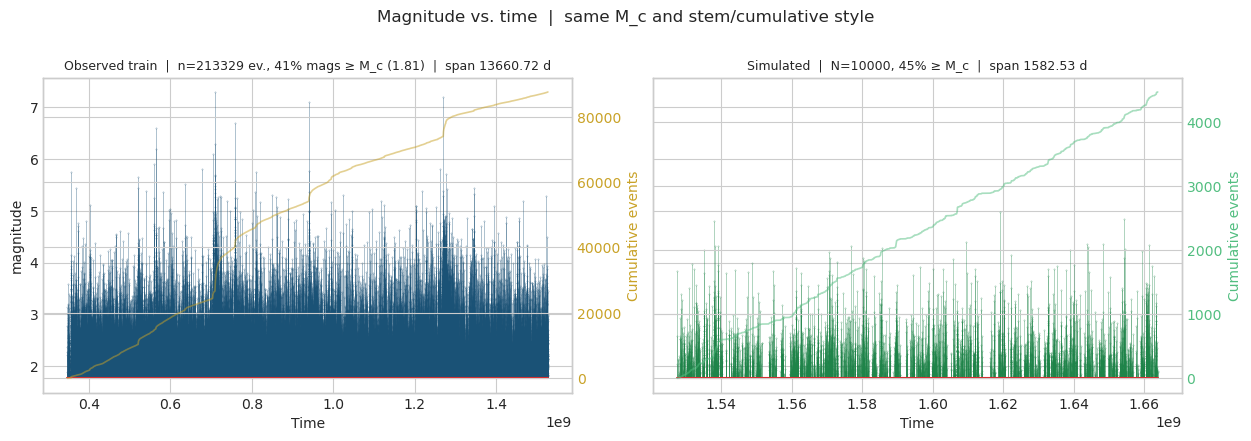

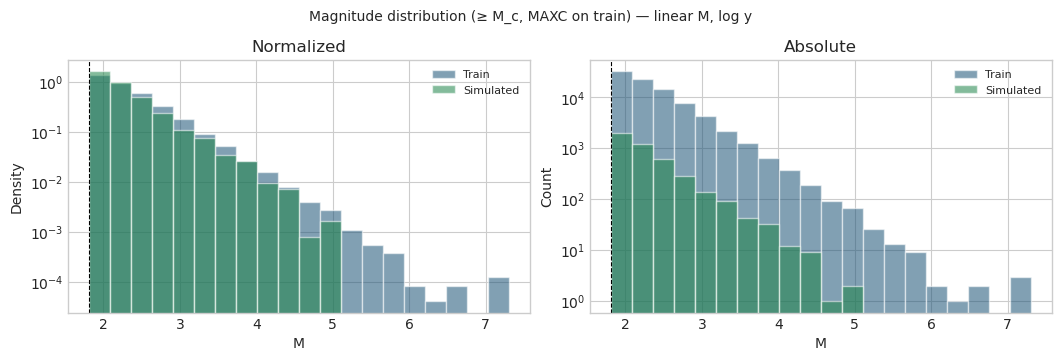

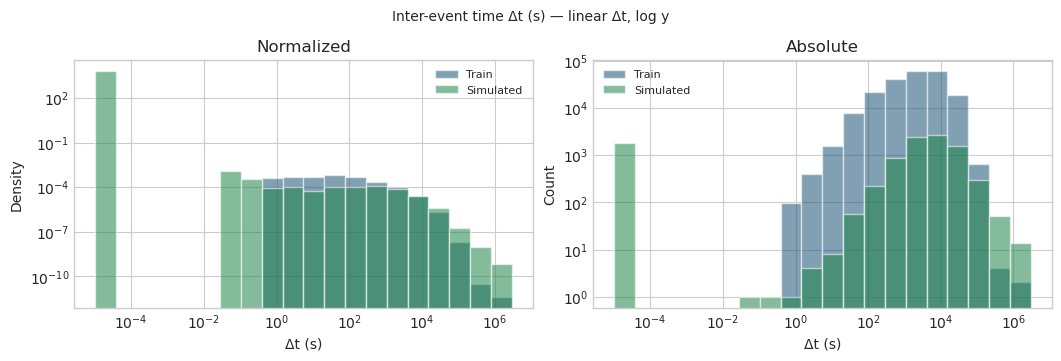

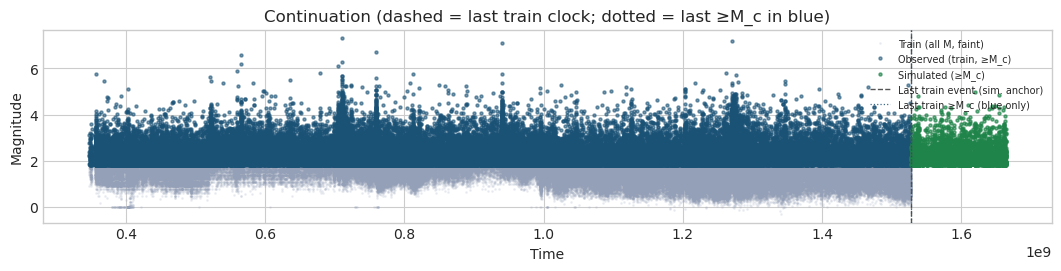

In [10]:
# Catalog visuals: train vs. simulated (run generation cell first)

if (not training_completed) or (data_pack is None):
    print("Run the training cell first.")
elif "simulated_catalog" not in globals():
    print("Run the generation cell to define `simulated_catalog`.")
else:
    _sim = globals().get("simulated_catalog")
    if _sim is None or len(_sim) == 0:
        print("`simulated_catalog` is empty; re-run generation.")
    else:
        n_tr = int(data_pack["n_train_events"])
        df0 = data_pack["df"]
        tcol = data_pack["time"]
        df_tr = df0.iloc[:n_tr].copy()
        sc = data_pack["scaler"]
        t_sim_anchor = float(df_tr["time"].iloc[-1])

        mc_train = float(
            catalog_analysis.estimate_completeness(
                df_tr["magnitude"], method="MAXC"
            )
        )
        n_tr_e = int(len(df_tr))
        p_above = (
            100.0
            * float((df_tr["magnitude"] >= mc_train).sum())
            / max(n_tr_e, 1)
        )
        t_span_tr = (
            float(df_tr["time"].iloc[-1] - df_tr["time"].iloc[0])
            if n_tr_e > 1
            else 0.0
        )

        # ---- A--B: paired stems (catalog-style)
        _style = (
            "seaborn-v0_8-whitegrid"
            if "seaborn-v0_8-whitegrid" in plt.style.available
            else "default"
        )
        with plt.style.context(_style):
            fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.8), sharey="row", constrained_layout=True)
            fig.suptitle("Magnitude vs. time  |  same M_c and stem/cumulative style", y=1.12, fontsize=12)

            plot_magnitude_time_like_catalog(
                df_tr, ax=axes[0], completeness=mc_train, stem_color="#1a5276", cum_color="#c9a227"
            )
            axes[0].set_title(
                "Observed train  |  n=%d ev., %d%% mags ≥ M_c (%.2f)  |  span %s"
                % (
                    n_tr_e,
                    int(round(p_above)),
                    mc_train,
                    f"{t_span_tr/86400.0:.2f} d" if t_span_tr > 3600 else f"{t_span_tr:.0f} s",
                ),
                fontsize=9,
            )

            dsim = simulated_to_event_df(_sim, t_sim_anchor)
            t_span_sim = float(dsim["time"].iloc[-1] - dsim["time"].iloc[0]) if len(dsim) > 1 else 0.0
            plot_magnitude_time_like_catalog(
                dsim, ax=axes[1], completeness=mc_train, stem_color="#1e8449", cum_color="#52be80"
            )
            axes[1].set_ylabel("")
            p_sim = (
                100.0
                * float((dsim["magnitude"] >= mc_train).sum())
                / max(len(dsim), 1)
            )
            axes[1].set_title(
                "Simulated  |  N=%d, %d%% ≥ M_c  |  span %s"
                % (
                    len(dsim),
                    int(round(p_sim)),
                    f"{t_span_sim/86400.0:.2f} d" if t_span_sim > 3600 else f"{t_span_sim:.0f} s",
                ),
                fontsize=9,
            )
            plt.show()

            # ---- C: magnitude distributions (log-linear y), train vs simulated overlaid
            m_tr = df_tr[df_tr["magnitude"] >= mc_train]["magnitude"].to_numpy()
            m_si = dsim[dsim["magnitude"] >= mc_train]["magnitude"].to_numpy()
            m_hi = max(
                float(m_tr.max()) if m_tr.size else mc_train,
                float(m_si.max()) if m_si.size else mc_train,
            )
            if m_hi <= mc_train:
                m_hi = mc_train + 0.5
            bins = np.linspace(mc_train, m_hi + 1e-6, 21)
            fig1, axh = plt.subplots(1, 2, figsize=(10.5, 3.2), constrained_layout=True)
            fig1.suptitle(
                "Magnitude distribution (≥ M_c, MAXC on train) — linear M, log y",
                y=1.08,
                fontsize=10,
            )
            axh[0].hist(
                m_tr,
                bins=bins,
                color="#1a5276",
                alpha=0.55,
                edgecolor="white",
                density=True,
                label="Train",
            )
            if m_si.size:
                axh[0].hist(
                    m_si,
                    bins=bins,
                    color="#1e8449",
                    alpha=0.55,
                    edgecolor="white",
                    density=True,
                    label="Simulated",
                )
            axh[0].axvline(mc_train, color="k", ls="--", lw=0.8)
            axh[0].set_yscale("log")
            axh[0].set_ylabel("Density")
            axh[0].set_xlabel("M")
            axh[0].legend(loc="best", fontsize=8)
            axh[0].set_title("Normalized")

            axh[1].hist(
                m_tr,
                bins=bins,
                color="#1a5276",
                alpha=0.55,
                edgecolor="white",
                label="Train",
            )
            if m_si.size:
                axh[1].hist(
                    m_si,
                    bins=bins,
                    color="#1e8449",
                    alpha=0.55,
                    edgecolor="white",
                    label="Simulated",
                )
            axh[1].axvline(mc_train, color="k", ls="--", lw=0.8)
            axh[1].set_yscale("log")
            axh[1].set_ylabel("Count")
            axh[1].set_xlabel("M")
            axh[1].legend(loc="best", fontsize=8)
            axh[1].set_title("Absolute")
            plt.show()

            # ---- C_dt: inter-event Δt distributions (train np.diff(time) vs simulated dt)
            dt_tr = np.diff(df_tr["time"].to_numpy().astype(np.float64))
            dt_tr = dt_tr[np.isfinite(dt_tr) & (dt_tr > 0)]
            dt_si = np.asarray(_sim["dt"], dtype=np.float64)
            dt_si = dt_si[np.isfinite(dt_si) & (dt_si > 0)]
            if dt_tr.size or dt_si.size:
                lo_dt = float(
                    min(
                        dt_tr.min() if dt_tr.size else np.inf,
                        dt_si.min() if dt_si.size else np.inf,
                    )
                )
                hi_dt = float(
                    max(
                        dt_tr.max() if dt_tr.size else -np.inf,
                        dt_si.max() if dt_si.size else -np.inf,
                    )
                )
                if not np.isfinite(lo_dt) or not np.isfinite(hi_dt):
                    lo_dt, hi_dt = 1e-6, 1.0
                if hi_dt <= lo_dt:
                    hi_dt = lo_dt + max(1.0, abs(lo_dt) * 0.01) + 1e-9
                # bins_dt = np.linspace(lo_dt, hi_dt + 1e-12, 21)
                bins_dt = np.logspace(np.log10(lo_dt), np.log10(hi_dt + 1e-12), 21)
                fig_dt, axd = plt.subplots(1, 2, figsize=(10.5, 3.2), constrained_layout=True)
                fig_dt.suptitle(
                    "Inter-event time Δt (s) — linear Δt, log y",
                    y=1.08,
                    fontsize=10,
                )
                if dt_tr.size:
                    axd[0].hist(
                        dt_tr,
                        bins=bins_dt,
                        color="#1a5276",
                        alpha=0.55,
                        edgecolor="white",
                        density=True,
                        label="Train",
                    )
                if dt_si.size:
                    axd[0].hist(
                        dt_si,
                        bins=bins_dt,
                        color="#1e8449",
                        alpha=0.55,
                        edgecolor="white",
                        density=True,
                        label="Simulated",
                    )
                axd[0].set_yscale("log")
                axd[0].set_ylabel("Density")
                axd[0].set_xlabel("Δt (s)")
                axd[0].legend(loc="best", fontsize=8)
                axd[0].set_title("Normalized")
                axd[0].set_xscale("log")
                if dt_tr.size:
                    axd[1].hist(
                        dt_tr,
                        bins=bins_dt,
                        color="#1a5276",
                        alpha=0.55,
                        edgecolor="white",
                        label="Train",
                    )
                if dt_si.size:
                    axd[1].hist(
                        dt_si,
                        bins=bins_dt,
                        color="#1e8449",
                        alpha=0.55,
                        edgecolor="white",
                        label="Simulated",
                    )
                axd[1].set_yscale("log")
                axd[1].set_ylabel("Count")
                axd[1].set_xlabel("Δt (s)")
                axd[1].legend(loc="best", fontsize=8)
                axd[1].set_title("Absolute")
                axd[1].set_xscale("log")
                plt.show()

            # ---- D: single time axis (continuation view)
            fig2, axt = plt.subplots(figsize=(10.5, 2.6), constrained_layout=True)
            c_tr = (df_tr["magnitude"] >= mc_train).to_numpy()
            c_si = (dsim["magnitude"] >= mc_train).to_numpy()
            axt.plot(
                df_tr["time"].to_numpy(),
                df_tr["magnitude"].to_numpy(),
                "o",
                ms=1.1,
                alpha=0.12,
                color="#94a0b8",
                label="Train (all M, faint)",
                zorder=1,
            )
            axt.plot(
                df_tr["time"].to_numpy()[c_tr],
                df_tr["magnitude"].to_numpy()[c_tr],
                "o",
                ms=2.2,
                alpha=0.55,
                color="#1a5276",
                label="Observed (train, ≥M_c)",
                zorder=2,
            )
            axt.plot(
                dsim["time"].to_numpy()[c_si],
                dsim["magnitude"].to_numpy()[c_si],
                "o",
                ms=2.2,
                alpha=0.65,
                color="#1e8449",
                label="Simulated (≥M_c)",
                zorder=2,
            )
            axt.axvline(
                t_sim_anchor,
                color="#555",
                ls="--",
                lw=1,
                label="Last train event (sim. anchor)",
                zorder=3,
            )
            if c_tr.any():
                axt.axvline(
                    float(df_tr["time"].to_numpy()[c_tr][-1]),
                    color="#1a5276",
                    ls=":",
                    lw=0.9,
                    alpha=0.85,
                    label="Last train ≥M_c (blue only)",
                    zorder=3,
                )
            axt.set_xlabel("Time")
            axt.set_ylabel("Magnitude")
            axt.set_title(
                "Continuation (dashed = last train clock; dotted = last ≥M_c in blue)"
            )
            axt.legend(loc="best", fontsize=7, framealpha=0.9)
            plt.show()



### Performance and predictions

Training loss by epoch, then **magnitude–time** views: train (catalog style) and test (true vs. mean prediction) in the previous section, then a single **train** batch: mixture posterior mean compared to targets. Scatter plots use **physical units** (seconds for inter-event time and catalog magnitude) via the scaler in `data_pack`.


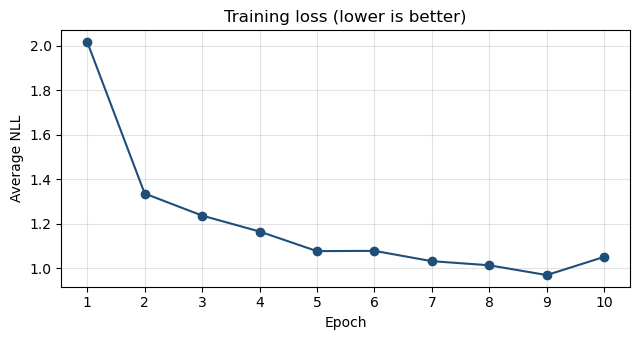

In [11]:
import matplotlib.pyplot as plt

if not training_completed or not epoch_loss_history:
    print("Run the training cell successfully first to plot loss.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    epochs_axis = np.arange(1, len(epoch_loss_history) + 1)
    ax.plot(epochs_axis, epoch_loss_history, "o-", color="#1f4e79", linewidth=1.5, markersize=6)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average NLL")
    ax.set_title("Training loss (lower is better)")
    ax.grid(True, alpha=0.35)
    ax.set_xticks(epochs_axis)
    plt.tight_layout()
    plt.show()


NLL on this batch (eval, training=False): 1.0785


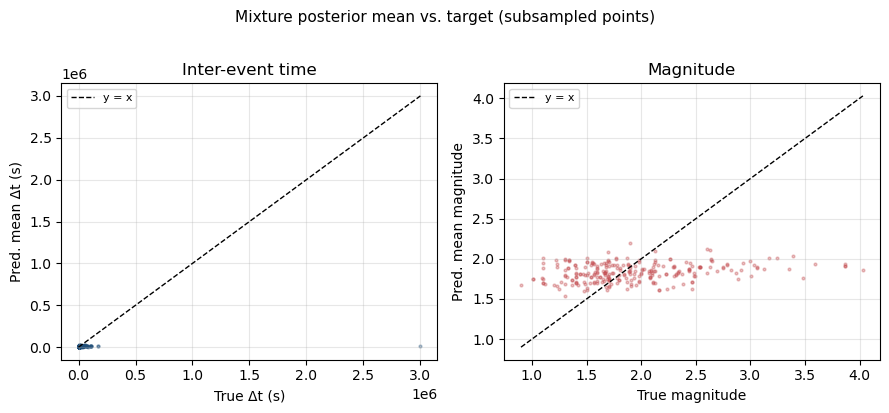

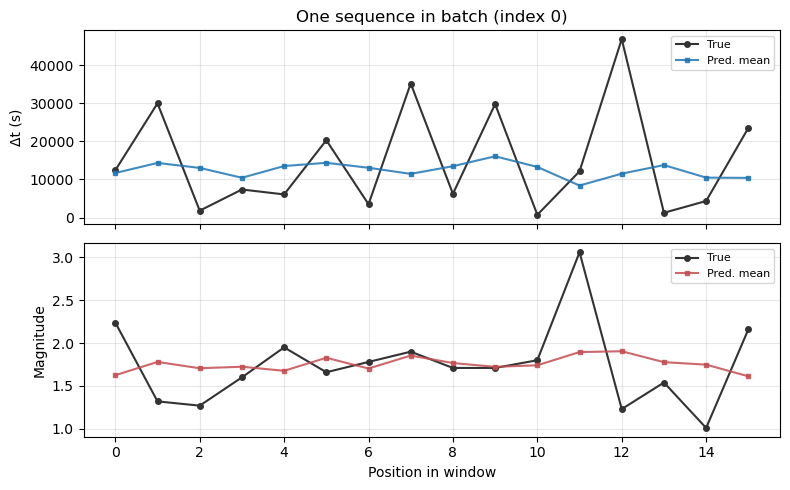

In [12]:
import matplotlib.pyplot as plt

def _denorm_sequences(x, scaler):
    """Map standardized \u0394t and magnitude back to physical units (inverse of `ml_utils.StandardScaler.transform`)."""
    return x * scaler.std + scaler.mean



if not training_completed:
    print("Run the training cell successfully first.")
else:
    batch_x, batch_y = next(iter(dataset))
    pi, mu, sigma = model(batch_x, training=False)
    pred_mean = mixture_posterior_mean(pi, mu, sigma)

    batch_nll = float(mdn_nll_bivariate(pi, mu, sigma, batch_y))
    print(f"NLL on this batch (eval, training=False): {batch_nll:.4f}")

    y_np = batch_y.numpy()
    p_np = pred_mean.numpy()
    flat_y = y_np.reshape(-1, 2)
    flat_p = p_np.reshape(-1, 2)

    rng = np.random.default_rng(42)
    n_scatter = min(4000, len(flat_y))
    ix = rng.choice(len(flat_y), size=n_scatter, replace=False)
    y_d = _denorm_sequences(flat_y[ix], scaler)
    p_d = _denorm_sequences(flat_p[ix], scaler)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    lims_dt = [
        min(y_d[:, 0].min(), p_d[:, 0].min()),
        max(y_d[:, 0].max(), p_d[:, 0].max()),
    ]
    lims_m = [
        min(y_d[:, 1].min(), p_d[:, 1].min()),
        max(y_d[:, 1].max(), p_d[:, 1].max()),
    ]
    axes[0].scatter(y_d[:, 0], p_d[:, 0], s=4, alpha=0.35, c="#1f4e79")
    axes[0].plot(lims_dt, lims_dt, "k--", linewidth=1, label="y = x")
    axes[0].set_xlabel("True Δt (s)")
    axes[0].set_ylabel("Pred. mean Δt (s)")
    axes[0].set_title("Inter-event time")
    axes[0].legend(loc="upper left", fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_d[:, 1], p_d[:, 1], s=4, alpha=0.35, c="#c44e52")
    axes[1].plot(lims_m, lims_m, "k--", linewidth=1, label="y = x")
    axes[1].set_xlabel("True magnitude")
    axes[1].set_ylabel("Pred. mean magnitude")
    axes[1].set_title("Magnitude")
    axes[1].legend(loc="upper left", fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.suptitle("Mixture posterior mean vs. target (subsampled points)", y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

    sample_idx = 0
    t_axis = np.arange(y_np.shape[1])
    y0 = _denorm_sequences(y_np[sample_idx : sample_idx + 1], scaler)[0]
    p0 = _denorm_sequences(p_np[sample_idx : sample_idx + 1], scaler)[0]

    fig2, axes2 = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes2[0].plot(t_axis, y0[:, 0], "o-", label="True", color="#333", markersize=4)
    axes2[0].plot(t_axis, p0[:, 0], "s-", label="Pred. mean", color="#1f77b4", markersize=3, alpha=0.85)
    axes2[0].set_ylabel("Δt (s)")
    axes2[0].set_title(f"One sequence in batch (index {sample_idx})")
    axes2[0].legend(loc="upper right", fontsize=8)
    axes2[0].grid(True, alpha=0.3)

    axes2[1].plot(t_axis, y0[:, 1], "o-", label="True", color="#333", markersize=4)
    axes2[1].plot(t_axis, p0[:, 1], "s-", label="Pred. mean", color="#c44e52", markersize=3, alpha=0.85)
    axes2[1].set_xlabel("Position in window")
    axes2[1].set_ylabel("Magnitude")
    axes2[1].legend(loc="upper right", fontsize=8)
    axes2[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
